# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [64]:
# Install any dependencies not pre-installed on Colab
!pip install -q "accelerate>=1.1.0" groq python-dotenv
print("✅ Dependencies ready")


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
✅ Dependencies ready


In [65]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.14.0
GPU available: False


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [66]:
LABEL_MAP = {
    "grounded": 0,
    "partially grounded": 1,
    "speculative": 2,
    "not assessable": 3,
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'grounded': 0, 'partially grounded': 1, 'speculative': 2, 'not assessable': 3}
Number of labels: 4


In [67]:


CSV_FILENAME = "takemeter_depth_0_1_2_annotated_with_notes.csv"
print(f"Select: {CSV_FILENAME}")
uploaded = CSV_FILENAME

if CSV_FILENAME not in uploaded:
    raise FileNotFoundError(
        f"Upload {CSV_FILENAME}; received: {list(uploaded)}"
    )

CSV_PATH = CSV_FILENAME
print(f"Uploaded: {CSV_PATH}")

Select: takemeter_depth_0_1_2_annotated_with_notes.csv
Uploaded: takemeter_depth_0_1_2_annotated_with_notes.csv


In [68]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# Match this CSV's columns to the notebook's expected names.
df = df.rename(columns={
    "comment_text": "text",
    "grounding_label": "label",
})

# Match the lowercase labels used in LABEL_MAP.
df["label"] = df["label"].astype(str).str.strip().str.lower()
df["text"] = df["text"].fillna("").astype(str)

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['post_id', 'post_title', 'comment_id', 'comment_depth', 'parent_comment_id', 'text', 'label', 'difficult_case_notes']
Total examples: 223

Label distribution:
label
grounded              104
partially grounded     60
not assessable         45
speculative            14
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [69]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 156 examples
Validation: 33 examples
Test: 34 examples

Train label distribution:
label
grounded              73
partially grounded    42
not assessable        31
speculative           10
Name: count, dtype: int64

Test label distribution:
label
grounded              16
partially grounded     9
not assessable         7
speculative            2
Name: count, dtype: int64


In [70]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map: 100%|██████████| 34/34 [00:00<00:00, 7676.50 examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [71]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9807.80it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 4


In [72]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [73]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.345716,1.326179,0.484848
2,1.320529,1.287007,0.454545
3,1.256526,1.219264,0.454545
4,1.188064,1.158407,0.454545
5,1.131199,1.105551,0.454545
6,1.055340,1.067094,0.454545
7,0.985700,1.040143,0.454545
8,0.920741,1.030952,0.484848


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  8.16it/s]



✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [74]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.471

Per-class metrics (fine-tuned model):
                    precision    recall  f1-score   support

          grounded       0.47      1.00      0.64        16
partially grounded       0.00      0.00      0.00         9
       speculative       0.00      0.00      0.00         2
    not assessable       0.00      0.00      0.00         7

          accuracy                           0.47        34
         macro avg       0.12      0.25      0.16        34
      weighted avg       0.22      0.47      0.30        34



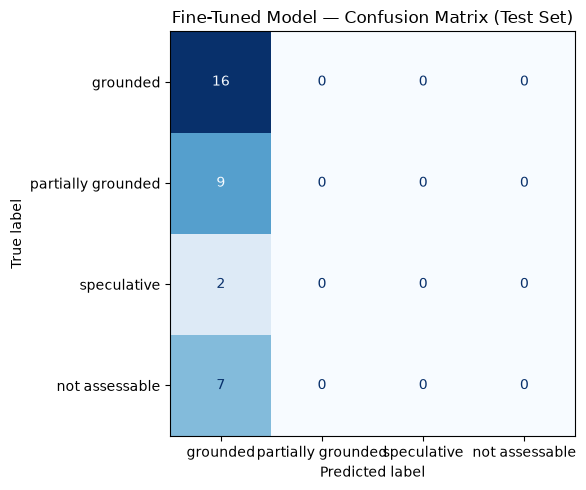

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [75]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [76]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 18 / 34

--- #1 ---
Text:      if you can’t see this comment as the best in show then get off the judges platform and sit with the civilians.
True:      not assessable
Predicted: grounded  (confidence: 0.28)

--- #2 ---
Text:      &gt;she had lost the title for it 

Oh hey! Don't forget to call the police and report it stolen. She effectively stole this vehicle from you and committed fraud along the way.
True:      partially grounded
Predicted: grounded  (confidence: 0.28)

--- #3 ---
Text:      YTA. move out so bro and sis can finally be together
True:      not assessable
Predicted: grounded  (confidence: 0.28)

--- #4 ---
Text:      My husband has an old Datsun Ute that he bought when he was 17! Years later it’s still partially complete in our yard, and has moved houses with us twice, about to come with us again for a third move....
True:      partially grounded
Predicted: grounded  (confidence: 0.29)

--- #5 ---
Text:      Right!? It's amazing how they even feel s

---
### Sample classifications for your README

Your evaluation report needs a **Sample Classifications** table: 3–5 posts with the predicted label
and its confidence, **including at least one correctly-predicted example** you explain.

The cell above only lists *wrong* predictions, so run this one to get a mix. It prints a ready-to-paste
markdown table — write it into your README as text, not a screenshot.

In [77]:
# Sample classifications table for your README (3-5 rows, correct + incorrect).
# Adjust the two counts if you want a different mix.

N_CORRECT, N_WRONG = 3, 2

correct_positions = np.where(ft_pred_ids == ft_true_ids)[0]
wrong_positions   = np.where(ft_pred_ids != ft_true_ids)[0]

if len(correct_positions) == 0:
    print("No correct predictions on the test set - check your label map and training run.")

sample = list(correct_positions[:N_CORRECT]) + list(wrong_positions[:N_WRONG])

print("| Post (truncated) | True label | Predicted | Confidence | Correct? |")
print("|---|---|---|---|---|")
for idx in sample:
    text = str(test_df.iloc[idx]["text"]).replace("|", "\\|").replace("\n", " ")
    if len(text) > 90:
        text = text[:90] + "..."
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    mark = "yes" if pred_label == true_label else "no"
    print(f"| {text} | {true_label} | {pred_label} | {confidence:.2f} | {mark} |")

print()
print("Paste this table into your README under 'Sample Classifications'.")
print("For at least one correct row, add a sentence on why that prediction is reasonable.")

| Post (truncated) | True label | Predicted | Confidence | Correct? |
|---|---|---|---|---|
| NTA.  Good for you for standing up for your daughter. The lock should stay. There would be... | grounded | grounded | 0.29 | yes |
| I’m devestated looking at these pictures. This is so messed up. I don’t know if you’ve hea... | grounded | grounded | 0.28 | yes |
| NTA. Sounds like you need to trade her in for a new gf - sounds like you dodged a bullet w... | grounded | grounded | 0.29 | yes |
| if you can’t see this comment as the best in show then get off the judges platform and sit... | not assessable | grounded | 0.28 | no |
| &gt;she had lost the title for it   Oh hey! Don't forget to call the police and report it ... | partially grounded | grounded | 0.28 | no |

Paste this table into your README under 'Sample Classifications'.
For at least one correct row, add a sentence on why that prediction is reasonable.


---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `meta-llama/llama-4-scout-17b-16e-instruct`.  
You need to write the classification prompt using your label definitions.

In [78]:
from groq import Groq
import os

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# In Colab, uncomment Option A below. Locally, set GROQ_API_KEY in your environment.
#
# Option A — Colab Secrets (recommended):
# from google.colab import userdata
# GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Local environment fallback:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access, or set the GROQ_API_KEY environment variable."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [79]:
SYSTEM_PROMPT = """
You classify the evidence grounding of Reddit comments from r/AmItheAsshole (AITA).

Judge how well a comment's reasoning is supported by the information available in the original post and, for replies, the relevant parent-comment context. Do not judge whether the AITA verdict is correct, whether the comment is polite, or whether it is long.

Assign each comment exactly one category:

grounded: The main reasoning is supported by explicit details from the post or conversation, a reasonable inference from those details, or relevant general knowledge without inventing case-specific facts.
Example: "Taking Zoey's makeup without permission and ruining it is not normal borrowing, so giving her a lock is a reasonable response."

partially grounded: The comment has a substantial evidence-based core but also includes unsupported assumptions, predictions, motives, or extrapolations that materially contribute to the argument.
Example: "The father is right to protect Zoey, and she will probably remember when she is older that he was the parent who supported her."

speculative: The central argument depends primarily on information that the post or conversation does not establish, especially invented motives, hidden history, personality claims, causal explanations, or confident predictions.
Example: "Sammy's attitude toward boundaries is probably the reason his marriage ended."

not assessable: The comment does not contain enough substantive reasoning to evaluate evidence grounding, such as a bare verdict, joke, short reaction, or simple agreement.
Example: "NTA."

Respond with ONLY one exact lowercase label and nothing else: grounded, partially grounded, speculative, or not assessable.
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1703 characters


In [80]:
def classify_with_groq(text):
    """Classify a single comment. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="openai/gpt-oss-120b",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this comment:\n\n{text}"},
            ],
            temperature=0,
            reasoning_effort="low",
            include_reasoning=False,
            max_completion_tokens=256,
        )
        raw = (response.choices[0].message.content or "").strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        if len(unparseable_responses) < 3:
            unparseable_responses.append(raw)
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
unparseable_responses = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Sample unparseable responses:", unparseable_responses)
else:
    print("\n✅ All model responses were parsed.")

Running baseline on 34 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/34 complete...
  20/34 complete...
  30/34 complete...

✅ All model responses were parsed.


In [81]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.265  (evaluated on 34/34 parseable responses)

Per-class metrics (baseline):
                    precision    recall  f1-score   support

          grounded       0.33      0.06      0.11        16
partially grounded       0.00      0.00      0.00         9
       speculative       0.09      0.50      0.15         2
    not assessable       0.37      1.00      0.54         7

          accuracy                           0.26        34
         macro avg       0.20      0.39      0.20        34
      weighted avg       0.24      0.26      0.17        34



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [82]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.265
Fine-tuned DistilBERT                  0.471
---------------------------------------------

Fine-tuning improvement: 0.206

Use these numbers in your README evaluation report.


In [83]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
